In [8]:
from typing import TypedDict

class AgentState(TypedDict):
    amount_usd: float
    total_usd: float
    total_zig: float

In [13]:
# Graph Nodes
def calc_total(state: AgentState) -> AgentState:
    '''Node to multiply usd by hour rate'''
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def convert_zig(state: AgentState) -> AgentState:
    '''Node to convert usd rate to zig'''
    state['total_zig'] = state['total_usd'] * 1.08
    return state


In [14]:
# build and compile graph
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)

# add Nodes

workflow.add_node("calc_total", calc_total)
workflow.add_node("convert_zig", convert_zig)

# Add edges

workflow.add_edge(START,"calc_total")
workflow.add_edge("calc_total","convert_zig")
workflow.add_edge("convert_zig",END)

# compile graph
graph = workflow.compile()

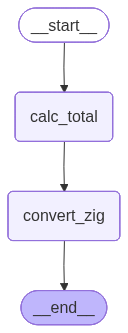

In [15]:
# Draw graph

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
graph.invoke({"amount_usd": 300})

{'amount_usd': 300, 'total_usd': 324.0, 'total_zig': 349.92}